# 01 - Comprensión y auditoría de calidad de los datos - OULAD

**Objetivo específico 1 (versión 2):** identificar y caracterizar las variables
académicas, conductuales y temporales, incorporando la auditoría formal de calidad que
la versión 1 no cubría. Este notebook reemplaza al 01 original e integra:

1. **Carga optimizada** (dtypes explícitos + categóricas: ~50% menos RAM en `studentVle`;
   exporta caché parquet).
2. **Detección de duplicados** — exactos y por llave natural — en las 7 tablas.
3. **Validación de rangos** y valores anómalos (scores, clics, pesos de evaluación).
4. **Consistencia lógica** entre tablas (retiros vs. matrículas, entregas sin
   inscripción, sitios no descritos).
5. **Integridad referencial** (v1) con verificación bidireccional de llaves.
6. **Caracterización de la variable objetivo** con la **segmentación del momento del
   retiro** (hallazgo crítico: 26,6% de abandonos antes del día 0).
7. Figuras con el estilo visual del proyecto, exportadas a PDF para el reporte
   `exploracion_inicial_oulad_v2.tex`.

Los conteos de la auditoría se exportan a `auditoria_crudos.json` para el reporte.

In [1]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb

# --- Estilo grafico del proyecto (Knaflic, 'Storytelling con datos') ---
# gris claro = contexto | azul #0073B1 = acento unico | naranja luminoso = solo riesgo/abandono
# degradado del mismo matiz para niveles ordenados | etiquetado directo, sin leyendas
GRIS, GRISOS, TINTA = '#D4D4D4', '#9B9B9B', '#404040'
ACENTO, RIESGO, AZUL_CLARO = '#0073B1', '#E8833A', '#C9E2F0'

def grad(n, c1=AZUL_CLARO, c2=ACENTO):
    a, b = np.array(to_rgb(c1)), np.array(to_rgb(c2))
    return [tuple(np.clip(a + (b - a) * i / max(n - 1, 1), 0, 1).tolist()) for i in range(n)]

plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 9, 'text.color': TINTA,
    'axes.edgecolor': GRISOS, 'axes.labelcolor': TINTA, 'axes.titlecolor': TINTA,
    'xtick.color': GRISOS, 'ytick.color': GRISOS,
    'xtick.labelcolor': TINTA, 'ytick.labelcolor': TINTA,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 120, 'savefig.bbox': 'tight'})

def limpiar(ax, y_grid=True):
    ax.spines['left'].set_visible(False); ax.tick_params(length=0)
    if y_grid:
        ax.yaxis.grid(True, color='#ECECEC', lw=.7); ax.set_axisbelow(True)

RAW_DIR = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed'); PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR = Path('../reportes/figs'); FIGS_DIR.mkdir(parents=True, exist_ok=True)
auditoria = {}

## 1. Carga optimizada de las 7 tablas

In [2]:
cat = 'category'
studentVle = pd.read_csv(RAW_DIR / 'studentVle.csv',
    dtype={'code_module': cat, 'code_presentation': cat, 'id_student': 'int32',
           'id_site': 'int32', 'date': 'int16', 'sum_click': 'int32'})
studentInfo = pd.read_csv(RAW_DIR / 'studentInfo.csv',
    dtype={'code_module': cat, 'code_presentation': cat, 'id_student': 'int32',
           'gender': cat, 'region': cat, 'highest_education': cat, 'imd_band': cat,
           'age_band': cat, 'num_of_prev_attempts': 'int8', 'studied_credits': 'int16',
           'disability': cat, 'final_result': cat})
studentRegistration = pd.read_csv(RAW_DIR / 'studentRegistration.csv',
    dtype={'code_module': cat, 'code_presentation': cat, 'id_student': 'int32'})
studentAssessment = pd.read_csv(RAW_DIR / 'studentAssessment.csv',
    dtype={'id_assessment': 'int32', 'id_student': 'int32', 'is_banked': 'int8'})
assessments = pd.read_csv(RAW_DIR / 'assessments.csv',
    dtype={'code_module': cat, 'code_presentation': cat, 'id_assessment': 'int32', 'assessment_type': cat})
vle = pd.read_csv(RAW_DIR / 'vle.csv',
    dtype={'id_site': 'int32', 'code_module': cat, 'code_presentation': cat, 'activity_type': cat})
courses = pd.read_csv(RAW_DIR / 'courses.csv', dtype={'code_module': cat, 'code_presentation': cat})

tablas = {'courses': courses, 'assessments': assessments, 'vle': vle, 'studentInfo': studentInfo,
          'studentRegistration': studentRegistration, 'studentAssessment': studentAssessment,
          'studentVle': studentVle}
for n_, d in tablas.items():
    print(f"{n_:22s} shape {str(d.shape):18s} memoria {d.memory_usage(deep=True).sum()/1e6:8.1f} MB")

courses                shape (22, 3)            memoria      0.0 MB
assessments            shape (206, 6)           memoria      0.0 MB
vle                    shape (6364, 6)          memoria      0.1 MB
studentInfo            shape (32593, 12)        memoria      0.5 MB
studentRegistration    shape (32593, 5)         memoria      0.7 MB
studentAssessment      shape (173912, 5)        memoria      4.3 MB
studentVle             shape (10655280, 6)      memoria    170.5 MB


## 2. Nulos, dtypes y cardinalidad por tabla

In [3]:
def resumen_tabla(d, nombre):
    r = pd.DataFrame({'dtype': d.dtypes.astype(str), 'n_nulos': d.isnull().sum(),
                      'pct_nulos': (d.isnull().mean()*100).round(2), 'n_unicos': d.nunique()})
    print(f"\n{'='*58}\n{nombre}\n{'='*58}"); print(r)
for n_, d in tablas.items():
    resumen_tabla(d, n_)


courses
                               dtype  n_nulos  pct_nulos  n_unicos
code_module                 category        0        0.0         7
code_presentation           category        0        0.0         4
module_presentation_length     int64        0        0.0         7

assessments
                      dtype  n_nulos  pct_nulos  n_unicos
code_module        category        0       0.00         7
code_presentation  category        0       0.00         4
id_assessment         int32        0       0.00       206
assessment_type    category        0       0.00         3
date                float64       11       5.34        74
weight              float64        0       0.00        24

vle
                      dtype  n_nulos  pct_nulos  n_unicos
id_site               int32        0       0.00      6364
code_module        category        0       0.00         7
code_presentation  category        0       0.00         4
activity_type      category        0       0.00        20
week_from

**Nulos identificados:** `assessments.date` (5,34%, evaluaciones tipo *Exam* sin fecha
prefijada), `studentInfo.imd_band` (3,41%) y `studentRegistration.date_registration`
(0,14%). `date_unregistration` es nulo por definición para quien no se retira. El
mecanismo de estos faltantes se estudia formalmente en el notebook 03.

## 3. Auditoría de duplicados (7 tablas)

Exactos y por llave natural. En `studentVle` la llave natural es (estudiante, módulo,
presentación, sitio, día); filas repetidas sobre esa llave representan sesiones
separadas del mismo día sobre el mismo recurso — estructura esperada que el feature
engineering **agrega por suma**, no elimina. Duplicados en las llaves de
`studentInfo`, `studentRegistration` o `studentAssessment` sí serían violaciones.

In [4]:
dup = {
 'courses_exactos': int(courses.duplicated().sum()),
 'assessments_id': int(assessments.duplicated('id_assessment').sum()),
 'vle_id_site': int(vle.duplicated('id_site').sum()),
 'studentInfo_exactos': int(studentInfo.duplicated().sum()),
 'studentInfo_llave': int(studentInfo.duplicated(['id_student','code_module','code_presentation']).sum()),
 'studentReg_llave': int(studentRegistration.duplicated(['id_student','code_module','code_presentation']).sum()),
 'studentAssess_llave': int(studentAssessment.duplicated(['id_student','id_assessment']).sum()),
 'studentVle_exactos': int(studentVle.duplicated().sum()),
 'studentVle_sesiones_mismo_dia_sitio': int(studentVle.duplicated(
     ['id_student','code_module','code_presentation','id_site','date']).sum()),
}
for k, v in dup.items(): print(f"{k:38s} {v:>10,}")
auditoria['duplicados'] = dup
assert dup['studentInfo_llave'] == 0 and dup['studentReg_llave'] == 0 and dup['studentAssess_llave'] == 0

courses_exactos                                 0
assessments_id                                  0
vle_id_site                                     0
studentInfo_exactos                             0
studentInfo_llave                               0
studentReg_llave                                0
studentAssess_llave                             0
studentVle_exactos                        787,170
studentVle_sesiones_mismo_dia_sitio     2,195,960


## 4. Rangos válidos, valores anómalos y consistencia lógica

In [5]:
rangos = {
 'score_fuera_0_100': int(((studentAssessment.score < 0) | (studentAssessment.score > 100)).sum()),
 'score_nulos': int(studentAssessment.score.isna().sum()),
 'sum_click_menor_1': int((studentVle.sum_click < 1).sum()),
 'sum_click_max': int(studentVle.sum_click.max()),
 'date_vle_rango': [int(studentVle.date.min()), int(studentVle.date.max())],
 'weight_negativo': int((assessments.weight < 0).sum()),
 'reg_rango': [float(studentRegistration.date_registration.min()),
               float(studentRegistration.date_registration.max())],
 'unreg_rango': [float(studentRegistration.date_unregistration.min()),
                 float(studentRegistration.date_unregistration.max())],
}
for k, v in rangos.items(): print(f"{k:22s} {v}")

pesos = assessments.groupby(['code_module','code_presentation'], observed=True)['weight'].sum()
rangos['cursos_pesos_distinto_200'] = int((pesos != 200).sum())
print(f"\nCursos con suma de pesos != 200 (100 continuo + 100 examen): {rangos['cursos_pesos_distinto_200']}")
auditoria['rangos'] = rangos

r = studentRegistration
cons = {'retiro_antes_matricula': int((r.date_unregistration < r.date_registration).sum())}
llaves_reg = set(map(tuple, r[['id_student','code_module','code_presentation']].values))
sa_ll = studentAssessment.merge(assessments[['id_assessment','code_module','code_presentation']], on='id_assessment')
cons['entregas_sin_inscripcion'] = len(set(map(tuple,
    sa_ll[['id_student','code_module','code_presentation']].drop_duplicates().values)) - llaves_reg)
cons['interacciones_sin_inscripcion'] = len(set(map(tuple,
    studentVle[['id_student','code_module','code_presentation']].drop_duplicates().values)) - llaves_reg)
cons['sitios_vle_no_descritos'] = len(set(studentVle.id_site.unique()) - set(vle.id_site.unique()))
for k, v in cons.items(): print(f"{k:32s} {v}")
auditoria['consistencia'] = cons

score_fuera_0_100      0
score_nulos            173
sum_click_menor_1      0
sum_click_max          6977
date_vle_rango         [-25, 269]
weight_negativo        0
reg_rango              [-322.0, 167.0]
unreg_rango            [-365.0, 444.0]

Cursos con suma de pesos != 200 (100 continuo + 100 examen): 5
retiro_antes_matricula           0
entregas_sin_inscripcion         0
interacciones_sin_inscripcion    0
sitios_vle_no_descritos          0


## 5. Integridad referencial bidireccional (v1, conservada)

In [6]:
ids_info = set(studentInfo.id_student.unique()); ids_reg = set(studentRegistration.id_student.unique())
ids_vle = set(studentVle.id_student.unique())
integ = {
 'estudiantes_info': len(ids_info), 'estudiantes_reg': len(ids_reg),
 'info_no_reg': len(ids_info - ids_reg), 'reg_no_info': len(ids_reg - ids_info),
 'vle_no_info': len(ids_vle - ids_info), 'info_sin_vle': len(ids_info - ids_vle),
}
cursos_c = set(map(tuple, courses[['code_module','code_presentation']].values))
cursos_i = set(map(tuple, studentInfo[['code_module','code_presentation']].drop_duplicates().values))
integ['cursos_coinciden'] = cursos_c == cursos_i
for k, v in integ.items(): print(f"{k:22s} {v}")
auditoria['integridad'] = {k: (v if not isinstance(v, bool) else str(v)) for k, v in integ.items()}
assert integ['info_no_reg'] == 0 and integ['reg_no_info'] == 0 and integ['vle_no_info'] == 0

estudiantes_info       28785
estudiantes_reg        28785
info_no_reg            0
reg_no_info            0
vle_no_info            0
info_sin_vle           2711
cursos_coinciden       True


**Unidad de análisis (hallazgo v1, conservado):** `studentInfo` tiene 32 593 filas pero
28 785 estudiantes únicos — la unidad efectiva es **estudiante × módulo × presentación**
(inscripción), no la persona. Los estudiantes sin registro alguno en `studentVle` son
los candidatos al abandono implícito que valida el notebook 02 v2.

## 6. Variable objetivo y momento del retiro

Definición A3.1: abandono = valor no nulo en `date_unregistration`. **Nuevo en v2:** la
segmentación temporal del retiro, que condiciona la definición de predicción temprana.

In [7]:
r = studentRegistration.copy()
r['abandono'] = r.date_unregistration.notnull().astype(int)
n_tot, n_ab = len(r), int(r.abandono.sum())
print(f"Total inscripciones: {n_tot:,} | abandono: {n_ab:,} ({n_ab/n_tot*100:.2f}%)")

VENTANA = 28
seg = np.select([r.date_unregistration.isna(), r.date_unregistration < 0, r.date_unregistration < VENTANA],
                ['sin_retiro', 'pre_inicio', 'en_ventana'], default='post_ventana')
r['momento_retiro'] = seg
resumen = (r.loc[r.abandono == 1, 'momento_retiro'].value_counts()
           .to_frame('n').assign(pct=lambda d: (d.n/n_ab*100).round(2)))
print(resumen)
auditoria['objetivo'] = {'n_total': n_tot, 'n_abandono': n_ab,
                         'momento_retiro': resumen.to_dict()}

Total inscripciones: 32,593 | abandono: 10,072 (30.90%)
                   n    pct
momento_retiro             
post_ventana    5032  49.96
pre_inicio      2678  26.59
en_ventana      2362  23.45


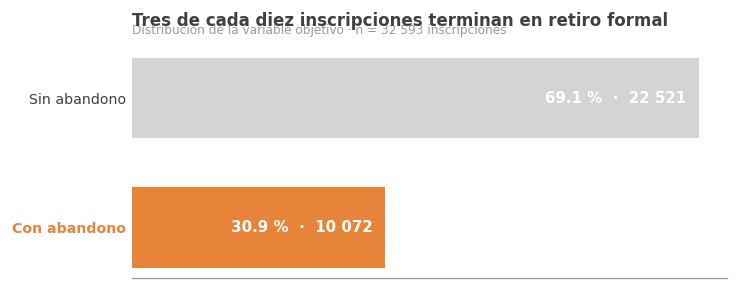

In [8]:
# Figura: variable objetivo
fig, ax = plt.subplots(figsize=(6.4, 2.5))
ax.barh([1, 0], [100 - n_ab/n_tot*100, n_ab/n_tot*100], color=[GRIS, RIESGO], height=.62)
ax.text(69.10-1.5, 1, f'{(n_tot-n_ab)/n_tot*100:.1f} %  ·  {n_tot-n_ab:,}'.replace(',',' '),
        va='center', ha='right', fontsize=9, color='white', fontweight='bold')
ax.text(n_ab/n_tot*100-1.5, 0, f'{n_ab/n_tot*100:.1f} %  ·  {n_ab:,}'.replace(',',' '),
        va='center', ha='right', fontsize=9, color='white', fontweight='bold')
ax.set_yticks([1, 0]); ax.set_yticklabels(['Sin abandono', 'Con abandono'], fontsize=8.5)
ax.get_yticklabels()[1].set(color=RIESGO, fontweight='bold')
ax.set_xticks([]); limpiar(ax, y_grid=False)
ax.set_title('Tres de cada diez inscripciones terminan en retiro formal',
             loc='left', fontsize=10, fontweight='bold', pad=13)
ax.text(0, 1.06, f'Distribución de la variable objetivo · n = {n_tot:,} inscripciones'.replace(',',' '),
        transform=ax.transAxes, fontsize=7.3, color=GRISOS)
plt.savefig(FIGS_DIR / 'fig_objetivo.pdf'); plt.show()

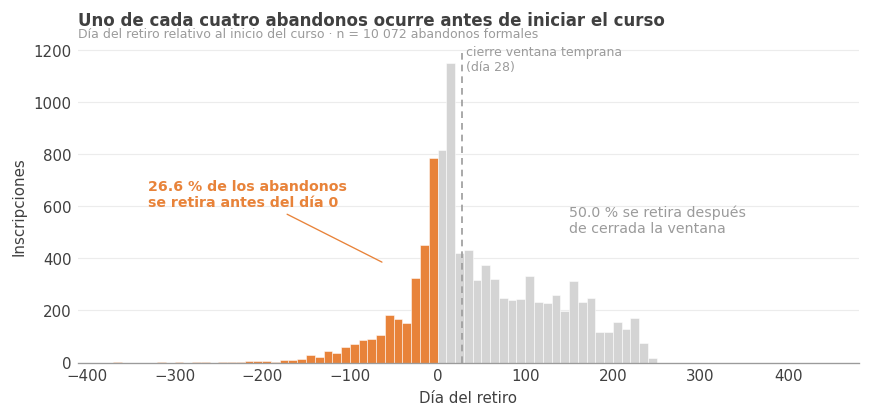

In [9]:
# Figura: momento del retiro
u = r.date_unregistration.dropna()
fig, ax = plt.subplots(figsize=(8.4, 3.4))
bins = np.arange(-370, 450, 10)
n_, b_, patches = ax.hist(u, bins=bins, color=GRIS, edgecolor='white', lw=.3)
for p, izq in zip(patches, b_[:-1]):
    if izq < 0: p.set_facecolor(RIESGO)
ax.axvline(28, color=GRISOS, lw=1, ls=(0, (4, 3)))
ax.text(32, ax.get_ylim()[1]*.93, 'cierre ventana temprana\n(día 28)', fontsize=7.5, color=GRISOS)
pct_pre = (u < 0).mean()*100; pct_post = (u >= 28).mean()*100
ax.annotate(f'{pct_pre:.1f} % de los abandonos\nse retira antes del día 0', xy=(-60, 380), xytext=(-330, 600),
            fontsize=8.5, color=RIESGO, fontweight='bold',
            arrowprops=dict(arrowstyle='-', color=RIESGO, lw=.8))
ax.text(150, 500, f'{pct_post:.1f} % se retira después\nde cerrada la ventana', fontsize=8.5, color=GRISOS)
limpiar(ax)
ax.set_title('Uno de cada cuatro abandonos ocurre antes de iniciar el curso',
             loc='left', fontsize=10, fontweight='bold', pad=14)
ax.text(0, 1.035, f'Día del retiro relativo al inicio del curso · n = {len(u):,} abandonos formales'.replace(',',' '),
        transform=ax.transAxes, fontsize=7.5, color=GRISOS)
ax.set_xlabel('Día del retiro'); ax.set_ylabel('Inscripciones')
plt.savefig(FIGS_DIR / 'fig_momento_retiro.pdf'); plt.show()

## 7. Interacciones previas al inicio (hallazgo v1, conservado)

In [10]:
n_pre = int((studentVle.date < 0).sum())
print(f"Interacciones con date < 0: {n_pre:,} ({n_pre/len(studentVle)*100:.2f}%) — "
      "se capturan como señal de compromiso anticipado en el 02 v2 (interaccion_pre_curso)")
auditoria['interacciones_pre_curso'] = {'n': n_pre, 'pct': round(n_pre/len(studentVle)*100, 2)}

Interacciones con date < 0: 688,988 (6.47%) — se capturan como señal de compromiso anticipado en el 02 v2 (interaccion_pre_curso)


## 8. Exportar caché, auditoría y hallazgos

Consolidado de hallazgos que condicionan el 02 v2 y el modelado:

1. **Duplicados y llaves:** sin violaciones en llaves de inscripción/entrega; las
   sesiones repetidas de `studentVle` se agregan por suma.
2. **Rangos:** verificar en la salida de la sección 4 — todo conteo > 0 inesperado se
   documenta en el reporte.
3. **Variable objetivo:** 30,90% de abandono, con 26,6% de los retiros **antes del
   día 0** y 23,4% dentro de la ventana → decisión del evento a predecir en el O3.
4. **Unidad de análisis:** inscripción (estudiante × módulo × presentación).
5. **Nulos localizados:** `assessments.date` 5,34% (Exam), `imd_band` 3,41%,
   `date_registration` 0,14% — mecanismo formal en el notebook 03.

In [11]:
studentVle.to_parquet(PROCESSED_DIR / 'studentVle.parquet', index=False)
with open(PROCESSED_DIR / 'auditoria_crudos.json', 'w') as f:
    json.dump(auditoria, f, indent=2, default=str)
print('Guardados: studentVle.parquet (cache) y auditoria_crudos.json')

Guardados: studentVle.parquet (cache) y auditoria_crudos.json
